<a href="https://colab.research.google.com/github/srijansxna/MachineLearningLab/blob/main/Lab2_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('housing.csv')
print("Dataset:\n")
print(df)

print("\nMissing values (True = missing):\n")
print(df.isnull())

print("\nNon-missing values (True = not missing):\n")
print(df.notnull())

missing_count = df.isnull().sum()

print("\nTotal missing values in each column:\n")
print(missing_count)


Dataset:

        RM  LSTAT  PTRATIO      MEDV
0    6.575   4.98     15.3  504000.0
1    6.421   9.14     17.8  453600.0
2    7.185   4.03     17.8  728700.0
3    6.998   2.94     18.7  701400.0
4    7.147   5.33     18.7  760200.0
..     ...    ...      ...       ...
484  6.593   9.67     21.0  470400.0
485  6.120   9.08     21.0  432600.0
486  6.976   5.64     21.0  501900.0
487  6.794   6.48     21.0  462000.0
488  6.030   7.88     21.0  249900.0

[489 rows x 4 columns]

Missing values (True = missing):

        RM  LSTAT  PTRATIO   MEDV
0    False  False    False  False
1    False  False    False  False
2    False  False    False  False
3    False  False    False  False
4    False  False    False  False
..     ...    ...      ...    ...
484  False  False    False  False
485  False  False    False  False
486  False  False    False  False
487  False  False    False  False
488  False  False    False  False

[489 rows x 4 columns]

Non-missing values (True = not missing):

       RM  L

In [ ]:
rows_before, cols_before = df.shape
print("Dataset size before cleaning:")
print("Rows:", rows_before, "Columns:", cols_before)

cleaned_df = df.dropna()

rows_after, cols_after = cleaned_df.shape
print("\nDataset size after cleaning:")
print("Rows:", rows_after, "Columns:", cols_after)

print("\nRows removed due to missing values:", rows_before - rows_after)

Dataset size before cleaning:
Rows: 489 Columns: 4

Dataset size after cleaning:
Rows: 489 Columns: 4

Rows removed due to missing values: 0


In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

for col in numerical_cols:
    df[col].fillna(df[col].mean(), inplace=True)
for col in categorical_cols:
    df[col].fillna('Unknown', inplace=True)

print("\nDataset after replacing missing values:\n")
print(df)


Dataset after replacing missing values:

        RM  LSTAT  PTRATIO      MEDV
0    6.575   4.98     15.3  504000.0
1    6.421   9.14     17.8  453600.0
2    7.185   4.03     17.8  728700.0
3    6.998   2.94     18.7  701400.0
4    7.147   5.33     18.7  760200.0
..     ...    ...      ...       ...
484  6.593   9.67     21.0  470400.0
485  6.120   9.08     21.0  432600.0
486  6.976   5.64     21.0  501900.0
487  6.794   6.48     21.0  462000.0
488  6.030   7.88     21.0  249900.0

[489 rows x 4 columns]


/tmp/ipython-input-4220980118.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [ ]:
if 'price' in df.columns:
    df['price'] = df['price'].astype(float)

if 'area' in df.columns:
    df['area'] = df['area'].astype(int)

if 'bedrooms' in df.columns:
    df['bedrooms'] = df['bedrooms'].astype(int)

if 'bathrooms' in df.columns:
    df['bathrooms'] = df['bathrooms'].astype(int)

print("\nColumn data types after conversion:\n")
print(df.dtypes)

print("\nSample data after conversion:\n")
df.head()


Column data types after conversion:

RM         float64
LSTAT      float64
PTRATIO    float64
MEDV       float64
dtype: object

Sample data after conversion:



,RM,LSTAT,PTRATIO,MEDV
0,6.575,4.98,15.3,504000.0
1,6.421,9.14,17.8,453600.0
2,7.185,4.03,17.8,728700.0
3,6.998,2.94,18.7,701400.0
4,7.147,5.33,18.7,760200.0


In [ ]:
df_renamed = df.rename(columns={
    'RM': 'Avg_Rooms',
    'LSTAT': 'Lower_Status_Pct',
    'PTRATIO': 'Pupil_Teacher_Ratio',
    'MEDV': 'Median_House_Value'
})

print("\nUpdated DataFrame with renamed columns:\n")
print(df_renamed.head())

print("\nUpdated column names:\n")
print(df_renamed.columns)


Updated DataFrame with renamed columns:

   Avg_Rooms  Lower_Status_Pct  Pupil_Teacher_Ratio  Median_House_Value
0      6.575              4.98                 15.3            504000.0
1      6.421              9.14                 17.8            453600.0
2      7.185              4.03                 17.8            728700.0
3      6.998              2.94                 18.7            701400.0
4      7.147              5.33                 18.7            760200.0

Updated column names:

Index(['Avg_Rooms', 'Lower_Status_Pct', 'Pupil_Teacher_Ratio',
       'Median_House_Value'],
      dtype='object')


In [ ]:
import numpy as np
import pandas as pd
print(df.describe())
df = df.replace({
    'RM': {0: np.nan},
    'LSTAT': {0: np.nan},
    'PTRATIO': {0: np.nan},
    'MEDV': {0: np.nan}
})

# Replace negative values with NaN
df[df < 0] = np.nan

# Fill corrected values using median
df = df.fillna(df.median())

print("\nCorrected Dataset:\n")
print(df.head())

               RM       LSTAT     PTRATIO          MEDV
count  489.000000  489.000000  489.000000  4.890000e+02
mean     6.240288   12.939632   18.516564  4.543429e+05
std      0.643650    7.081990    2.111268  1.653403e+05
min      3.561000    1.980000   12.600000  1.050000e+05
25%      5.880000    7.370000   17.400000  3.507000e+05
50%      6.185000   11.690000   19.100000  4.389000e+05
75%      6.575000   17.120000   20.200000  5.187000e+05
max      8.398000   37.970000   22.000000  1.024800e+06

Corrected Dataset:

      RM  LSTAT  PTRATIO      MEDV
0  6.575   4.98     15.3  504000.0
1  6.421   9.14     17.8  453600.0
2  7.185   4.03     17.8  728700.0
3  6.998   2.94     18.7  701400.0
4  7.147   5.33     18.7  760200.0


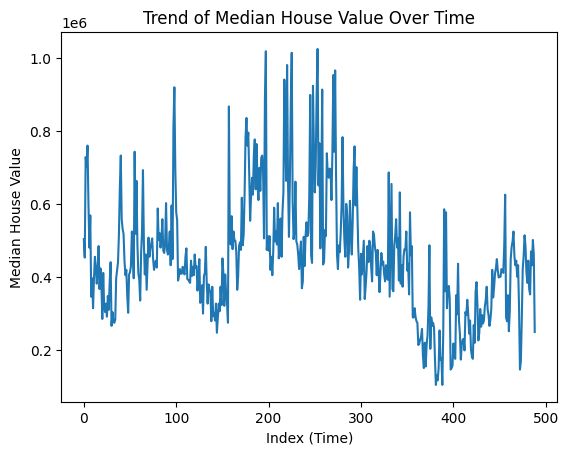

In [ ]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(df.index, df['MEDV'])
plt.xlabel("Index (Time)")
plt.ylabel("Median House Value")
plt.title("Trend of Median House Value Over Time")
plt.show()

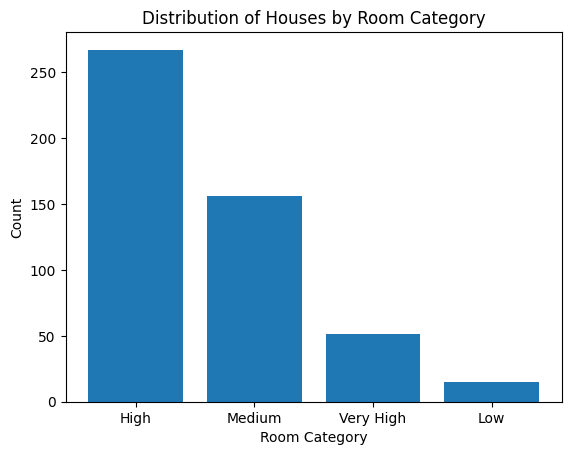

In [ ]:
df['Room_Category'] = pd.cut(
    df['RM'],
    bins=[0, 5, 6, 7, 10],
    labels=['Low', 'Medium', 'High', 'Very High']
)
category_counts = df['Room_Category'].value_counts()

plt.figure()
plt.bar(category_counts.index, category_counts.values)
plt.xlabel("Room Category")
plt.ylabel("Count")
plt.title("Distribution of Houses by Room Category")
plt.show()

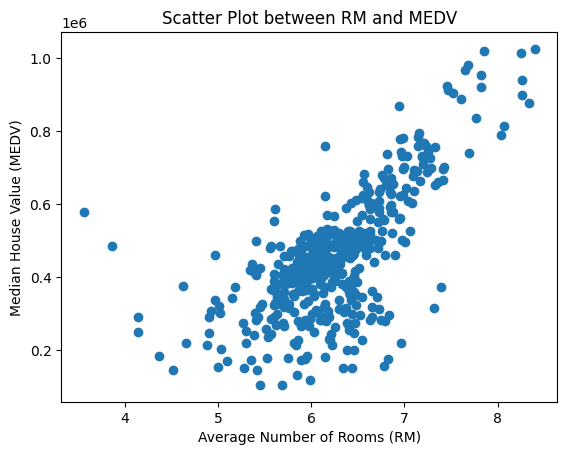

In [ ]:
plt.figure()
plt.scatter(df['RM'], df['MEDV'])
plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("Median House Value (MEDV)")
plt.title("Scatter Plot between RM and MEDV")
plt.show()

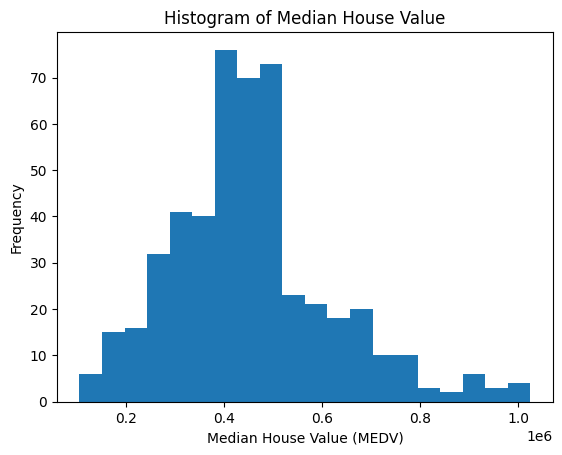

np.float64(0.7750823014749909)

In [ ]:
feature = 'MEDV'


plt.figure()
plt.hist(df[feature], bins=20)
plt.xlabel("Median House Value (MEDV)")
plt.ylabel("Frequency")
plt.title("Histogram of Median House Value")
plt.show()

skewness = df[feature].skew()
skewness

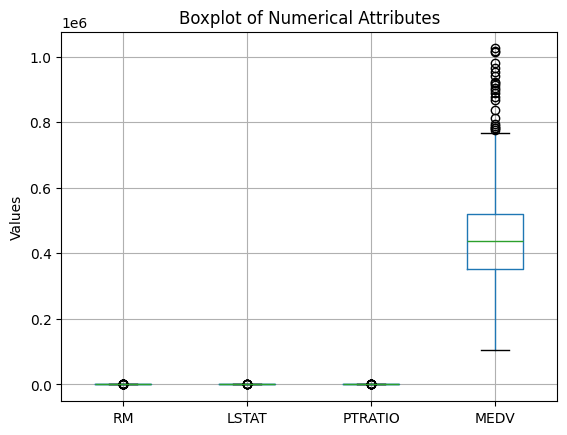

,RM,LSTAT,PTRATIO,MEDV
count,489.000000,489.000000,489.000000,4.890000e+02
mean,6.240288,12.939632,18.516564,4.543429e+05
std,0.643650,7.081990,2.111268,1.653403e+05
min,3.561000,1.980000,12.600000,1.050000e+05
25%,5.880000,7.370000,17.400000,3.507000e+05
50%,6.185000,11.690000,19.100000,4.389000e+05
75%,6.575000,17.120000,20.200000,5.187000e+05
max,8.398000,37.970000,22.000000,1.024800e+06


In [ ]:
plt.figure()
df.boxplot(column=['RM', 'LSTAT', 'PTRATIO', 'MEDV'])
plt.title("Boxplot of Numerical Attributes")
plt.ylabel("Values")
plt.show()

# Display summary statistics for interpretation
df.describe()